# ISPRA Rifiuti Urbani — costi, efficienza e profili territoriali (v2)

**Domanda guida:** chi spende di piu nella gestione dei rifiuti differenzia meglio, oppure l'efficienza non segue la spesa?

Questo notebook unisce due logiche:
- il `progetto-pilota`, che fornisce la grammatica dei quadranti e dei cluster;
- il candidate `ispra-ru-costi-kg`, che aggiunge la dimensione dei costi.

Perimetro operativo del `v2`:
- base principale: `2024`;
- contesto evolutivo: `2020`, `2023`, `2024`;
- ponte metodologico con il pilota: confronto `2020 -> 2023`.


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'candidates').exists() and (p / 'out').exists():
            return p
    return Path.cwd().parents[2]


ROOT = _find_repo_root()
BASE = ROOT / 'out' / 'data' / 'mart' / 'ispra_ru_base'
available_years = sorted([int(p.parent.name) for p in BASE.glob('*/mart_compose_v2.parquet')])
print(f'Anni disponibili per mart_compose_v2: {available_years}')

paths = [(BASE / str(y) / 'mart_compose_v2.parquet').as_posix() for y in available_years]
union_sql = ' UNION ALL '.join([f"SELECT * FROM read_parquet('{p}')" for p in paths])
con = duckdb.connect()


Anni disponibili per mart_compose_v2: [2020, 2023, 2024]


## 1. Copertura e perimetro

Obiettivo di questa sezione:
- chiarire quali anni entrano davvero nel `v2`;
- distinguere perimetro RU completo e perimetro joinato `A + B + C`;
- fissare subito i limiti del dataset prima dei grafici.


Anni disponibili nel mart_compose_v2: [2020, 2023, 2024]
Anni mancanti nel clone corrente: [2021, 2022]
Nota: il quadrante_costo e calcolato solo sul 2024 per design, quindi nel 2020 e nel 2023 resta nullo.


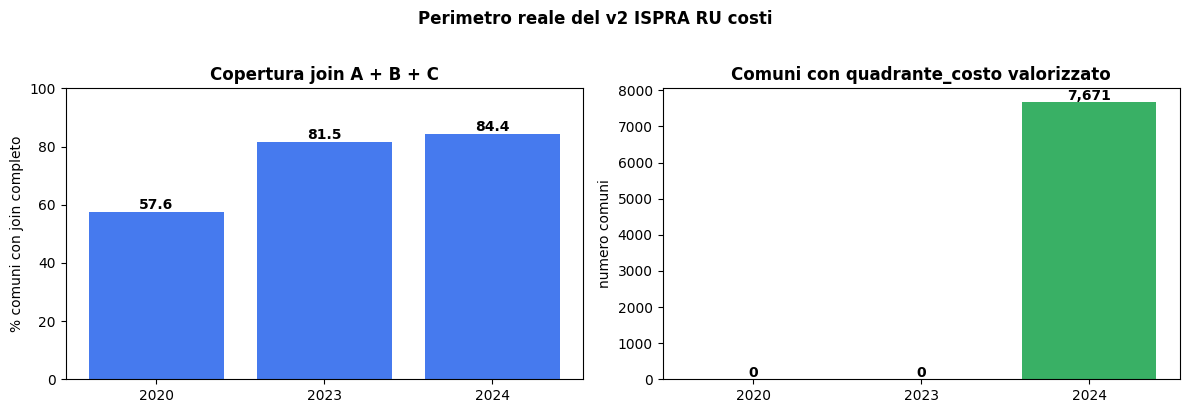

In [2]:
coverage = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        anno,
        COUNT(*) AS comuni_ru,
        CAST(SUM(CASE WHEN join_b_ok AND join_c_ok THEN 1 ELSE 0 END) AS BIGINT) AS comuni_join,
        ROUND(100.0 * SUM(CASE WHEN join_b_ok AND join_c_ok THEN 1 ELSE 0 END) / COUNT(*), 1) AS copertura_pct,
        CAST(SUM(CASE WHEN quadrante_costo IS NOT NULL THEN 1 ELSE 0 END) AS BIGINT) AS comuni_quadrante
    FROM t
    GROUP BY anno
    ORDER BY anno
"""
).df()

missing_years = []
if available_years:
    missing_years = sorted(set(range(min(available_years), max(available_years) + 1)) - set(available_years))

print('Anni disponibili nel mart_compose_v2:', available_years)
print('Anni mancanti nel clone corrente:', missing_years if missing_years else 'nessuno')
print('Nota: il quadrante_costo e calcolato solo sul 2024 per design, quindi nel 2020 e nel 2023 resta nullo.')
coverage

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(coverage['anno'].astype(str), coverage['copertura_pct'], color='#2563EB', alpha=0.85)
for i, v in enumerate(coverage['copertura_pct']):
    axes[0].text(i, float(v) + 1, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Copertura join A + B + C', fontweight='bold')
axes[0].set_ylabel('% comuni con join completo')
axes[0].set_ylim(0, 100)

axes[1].bar(coverage['anno'].astype(str), coverage['comuni_quadrante'], color='#16A34A', alpha=0.85)
for i, v in enumerate(coverage['comuni_quadrante']):
    axes[1].text(i, float(v) + 60, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Comuni con quadrante_costo valorizzato', fontweight='bold')
axes[1].set_ylabel('numero comuni')

plt.suptitle('Perimetro reale del v2 ISPRA RU costi', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 2. Ponte con il progetto-pilota

Qui riusiamo la logica del pilota senza dipendere dai suoi artifact locali:
- `istat_comune_6` documentato come stringa a 6 cifre;
- quadranti del pilota letti come grammatica metodologica;
- cluster demografico usato come confronto, non come verita esterna.


In [3]:
print('Contratto chiave lato pilota: istat_comune_6 documentato come stringa a 6 cifre.')
print('Contratto chiave lato cross mart: codice_comune_istat verificato come VARCHAR a 6 cifre.')

bridge_2020_2023 = con.execute(
    f"""WITH t AS ({union_sql}),
    p AS (
        SELECT
            codice_comune_istat,
            MAX(CASE WHEN anno = 2020 THEN percentuale_rd END) AS rd_2020,
            MAX(CASE WHEN anno = 2023 THEN percentuale_rd END) AS rd_2023,
            MAX(CASE WHEN anno = 2020 THEN totale_ru_tonnellate END) AS ru_2020,
            MAX(CASE WHEN anno = 2023 THEN totale_ru_tonnellate END) AS ru_2023,
            MAX(CASE WHEN anno = 2020 THEN kg_ru_per_abitante_calc END) AS kg_2020,
            MAX(CASE WHEN anno = 2023 THEN kg_ru_per_abitante_calc END) AS kg_2023
        FROM t
        WHERE anno IN (2020, 2023)
          AND join_b_ok
          AND join_c_ok
        GROUP BY codice_comune_istat
    )
    SELECT
        codice_comune_istat,
        rd_2020,
        rd_2023,
        ru_2020,
        ru_2023,
        kg_2020,
        kg_2023,
        ROUND(rd_2023 - rd_2020, 2) AS delta_rd_pp,
        ROUND(ru_2023 - ru_2020, 3) AS delta_ru_t,
        ROUND(kg_2023 - kg_2020, 2) AS delta_kg_ab,
        CASE
            WHEN rd_2020 IS NULL OR rd_2023 IS NULL OR ru_2020 IS NULL OR ru_2023 IS NULL THEN 'Dati mancanti'
            WHEN rd_2023 >= rd_2020 AND ru_2023 < ru_2020 THEN 'Virtuosi (RD su, RU giu)'
            WHEN rd_2023 >= rd_2020 AND ru_2023 >= ru_2020 THEN 'Migliora RD ma aumenta RU (RD su, RU su)'
            WHEN rd_2023 < rd_2020 AND ru_2023 < ru_2020 THEN 'Riduce RU ma non RD (RD giu, RU giu)'
            ELSE 'Peggiora entrambi (RD giu, RU su)'
        END AS quadrante_pilota_minimo
    FROM p
"""
).df()

bridge_summary = con.execute(
    f"""WITH t AS ({union_sql}),
    p AS (
        SELECT
            codice_comune_istat,
            MAX(CASE WHEN anno = 2020 THEN percentuale_rd END) AS rd_2020,
            MAX(CASE WHEN anno = 2023 THEN percentuale_rd END) AS rd_2023,
            MAX(CASE WHEN anno = 2020 THEN totale_ru_tonnellate END) AS ru_2020,
            MAX(CASE WHEN anno = 2023 THEN totale_ru_tonnellate END) AS ru_2023,
            MAX(CASE WHEN anno = 2020 THEN kg_ru_per_abitante_calc END) AS kg_2020,
            MAX(CASE WHEN anno = 2023 THEN kg_ru_per_abitante_calc END) AS kg_2023
        FROM t
        WHERE anno IN (2020, 2023)
          AND join_b_ok
          AND join_c_ok
        GROUP BY codice_comune_istat
    )
    SELECT
        COUNT(*) AS comuni,
        ROUND(AVG(rd_2023 - rd_2020), 2) AS delta_rd_pp_medio,
        ROUND(AVG(kg_2023 - kg_2020), 2) AS delta_kg_ab_medio,
        CAST(SUM(CASE WHEN rd_2023 >= rd_2020 AND ru_2023 < ru_2020 THEN 1 ELSE 0 END) AS BIGINT) AS comuni_virtuosi,
        CAST(SUM(CASE WHEN rd_2023 >= rd_2020 AND ru_2023 >= ru_2020 THEN 1 ELSE 0 END) AS BIGINT) AS rd_su_ru_su
    FROM p
"""
).df()

bridge_quadrants = (
    bridge_2020_2023['quadrante_pilota_minimo']
    .value_counts(dropna=False)
    .rename_axis('quadrante_pilota_minimo')
    .reset_index(name='n_comuni')
)

bridge_summary
bridge_quadrants


Contratto chiave lato pilota: istat_comune_6 documentato come stringa a 6 cifre.
Contratto chiave lato cross mart: codice_comune_istat verificato come VARCHAR a 6 cifre.


,quadrante_pilota_minimo,n_comuni
0,Dati mancanti,2848
1,"Migliora RD ma aumenta RU (RD su, RU su)",1190
2,"Virtuosi (RD su, RU giu)",1014
3,"Riduce RU ma non RD (RD giu, RU giu)",942
4,"Peggiora entrambi (RD giu, RU su)",753


## 3. Nuova dimensione: costo e performance nel 2024

Questa e la sezione centrale del `v2`.
La classificazione `quadrante_costo` e descrittiva e si basa su:
- mediana `%RD` 2024 del campione joinato;
- mediana `costo_totale_euro_ab` 2024 dello stesso campione.


Soglia RD 2024: 73.63
Soglia costo 2024: 170.065


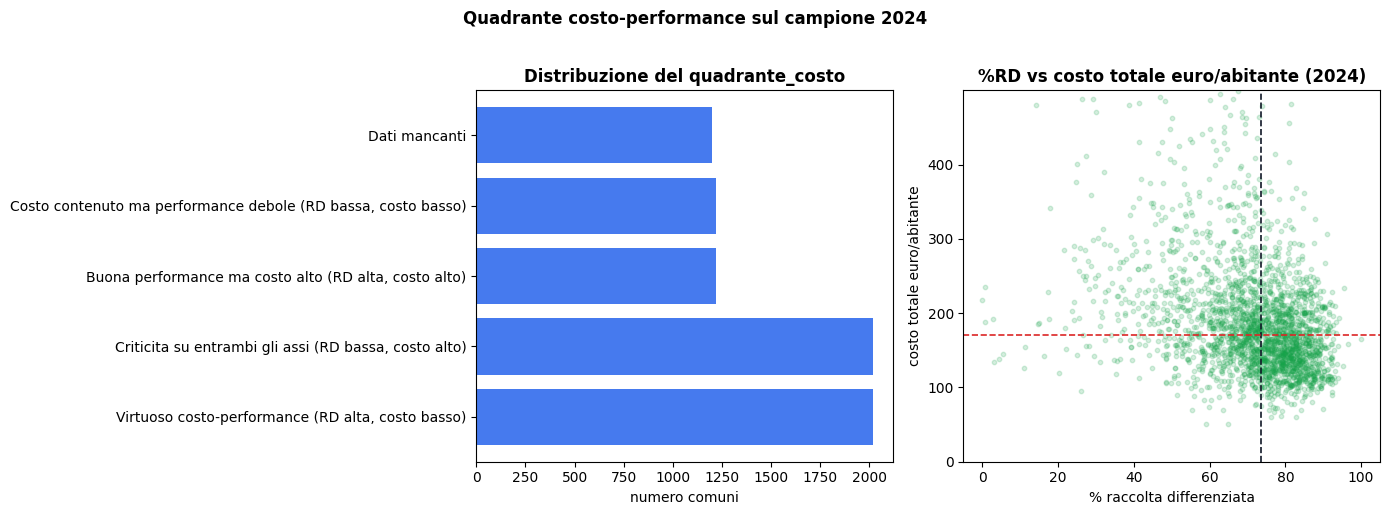

,quadrante_costo,comune,regione,pct_rd,costo_ab
0,"Buona performance ma costo alto (RD alta, costo alto)",MONTEROSSO AL MARE,Liguria,73.87,"1,399.88"
1,"Buona performance ma costo alto (RD alta, costo alto)",FORTE DEI MARMI,Toscana,77.26,998.69
2,"Costo contenuto ma performance debole (RD bassa, costo basso)",AVERARA,Lombardia,42.75,170.04
3,"Costo contenuto ma performance debole (RD bassa, costo basso)",BAIRO,Piemonte,69.59,170.03
4,"Criticita su entrambi gli assi (RD bassa, costo alto)",FOPPOLO,Lombardia,37.98,"1,478.30"
5,"Criticita su entrambi gli assi (RD bassa, costo alto)",SAUZE DOULX,Piemonte,50.12,"1,268.45"
6,"Virtuoso costo-performance (RD alta, costo basso)",PALAZZAGO,Lombardia,82.94,59.89
7,"Virtuoso costo-performance (RD alta, costo basso)",SELVA DEI MOLINI,Trentino-Alto Adige,76.33,60.25


In [4]:
joined_2024 = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT *
    FROM t
    WHERE anno = 2024
"""
).df()

quad_summary = (
    joined_2024['quadrante_costo']
    .value_counts(dropna=False)
    .rename_axis('quadrante_costo')
    .reset_index(name='n_comuni')
)

print('Soglia RD 2024:', round(float(joined_2024['soglia_rd_2024'].dropna().iloc[0]), 2))
print('Soglia costo 2024:', round(float(joined_2024['soglia_costo_euro_ab_2024'].dropna().iloc[0]), 3))
quad_summary

sample = joined_2024[(joined_2024['join_b_ok']) & (joined_2024['join_c_ok'])].sample(
    min(len(joined_2024[(joined_2024['join_b_ok']) & (joined_2024['join_c_ok'])]), 2500),
    random_state=42
)
rd_threshold = float(joined_2024['soglia_rd_2024'].dropna().iloc[0])
costo_threshold = float(joined_2024['soglia_costo_euro_ab_2024'].dropna().iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(quad_summary['quadrante_costo'], quad_summary['n_comuni'], color='#2563EB', alpha=0.85)
axes[0].set_title('Distribuzione del quadrante_costo', fontweight='bold')
axes[0].set_xlabel('numero comuni')

axes[1].scatter(sample['percentuale_rd'], sample['costo_totale_euro_ab'], alpha=0.18, s=10, color='#16A34A')
axes[1].axvline(rd_threshold, color='#111827', linestyle='--', linewidth=1.2)
axes[1].axhline(costo_threshold, color='#DC2626', linestyle='--', linewidth=1.2)
axes[1].set_title('%RD vs costo totale euro/abitante (2024)', fontweight='bold')
axes[1].set_xlabel('% raccolta differenziata')
axes[1].set_ylabel('costo totale euro/abitante')
axes[1].set_ylim(0, min(float(sample['costo_totale_euro_ab'].quantile(0.98)) * 1.1, 1600))

plt.suptitle('Quadrante costo-performance sul campione 2024', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

quad_examples = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        quadrante_costo,
        comune,
        regione,
        ROUND(percentuale_rd, 2) AS pct_rd,
        ROUND(costo_totale_euro_ab, 2) AS costo_ab
    FROM t
    WHERE anno = 2024
      AND quadrante_costo <> 'Dati mancanti'
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY quadrante_costo
        ORDER BY CASE
            WHEN quadrante_costo = 'Virtuoso costo-performance (RD alta, costo basso)' THEN costo_totale_euro_ab
            ELSE -costo_totale_euro_ab
        END ASC
    ) <= 2
    ORDER BY quadrante_costo,
        CASE
            WHEN quadrante_costo = 'Virtuoso costo-performance (RD alta, costo basso)' THEN costo_totale_euro_ab
            ELSE -costo_totale_euro_ab
        END ASC
"""
).df()
quad_examples


## 4. Focus Nord / Centro / Sud

In questa sezione leggiamo se il divario territoriale e strutturale oppure se cambia molto quando guardiamo insieme:
- costo per abitante;
- RU pro capite;
- percentuale di raccolta differenziata.


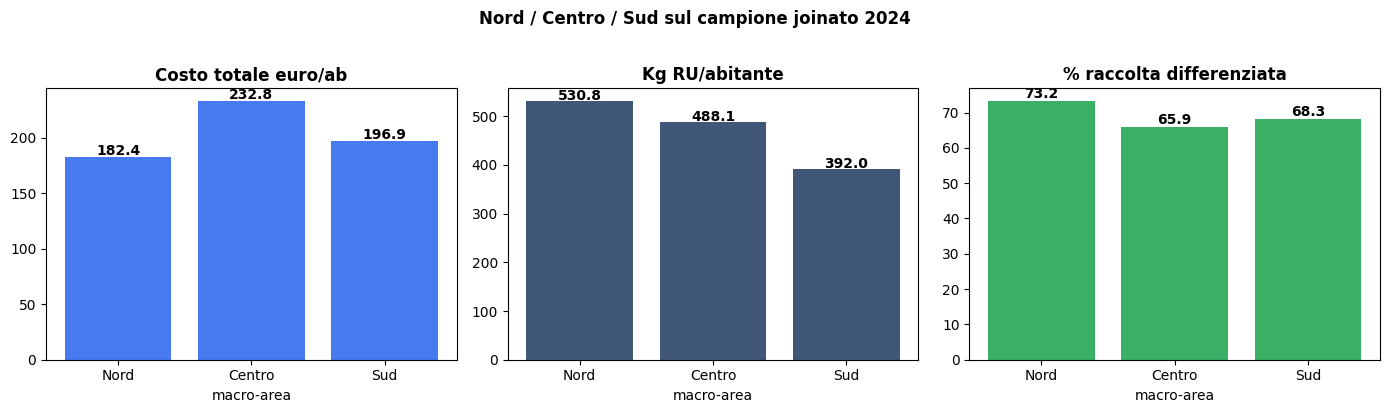

In [5]:
macro_summary = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        regione_macro,
        COUNT(*) AS n_comuni,
        ROUND(AVG(costo_totale_euro_ab), 1) AS costo_ab,
        ROUND(AVG(kg_ru_per_abitante_calc), 1) AS kg_ab,
        ROUND(AVG(percentuale_rd), 1) AS pct_rd
    FROM t
    WHERE anno = 2024
      AND join_b_ok
      AND join_c_ok
      AND regione_macro <> 'N/D'
    GROUP BY regione_macro
    ORDER BY CASE regione_macro WHEN 'Nord' THEN 1 WHEN 'Centro' THEN 2 WHEN 'Sud' THEN 3 ELSE 4 END
"""
).df()
macro_summary

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ('costo_ab', 'Costo totale euro/ab', '#2563EB'),
    ('kg_ab', 'Kg RU/abitante', '#1E3A5F'),
    ('pct_rd', '% raccolta differenziata', '#16A34A'),
]
for ax, (col, title, color) in zip(axes, metrics):
    ax.bar(macro_summary['regione_macro'], macro_summary[col], color=color, alpha=0.85)
    for i, v in enumerate(macro_summary[col]):
        ax.text(i, float(v) + (2 if col != 'pct_rd' else 0.8), str(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('macro-area')
plt.suptitle('Nord / Centro / Sud sul campione joinato 2024', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Lettura interpretativa da aggiungere solo dopo il run finale del notebook.


## 5. Cluster demografico

Qui riprendiamo il linguaggio del pilota e lo usiamo sulla nuova dimensione dei costi.
Il cluster corrente e derivato dalla `popolazione` presente nel cross mart `2024`.


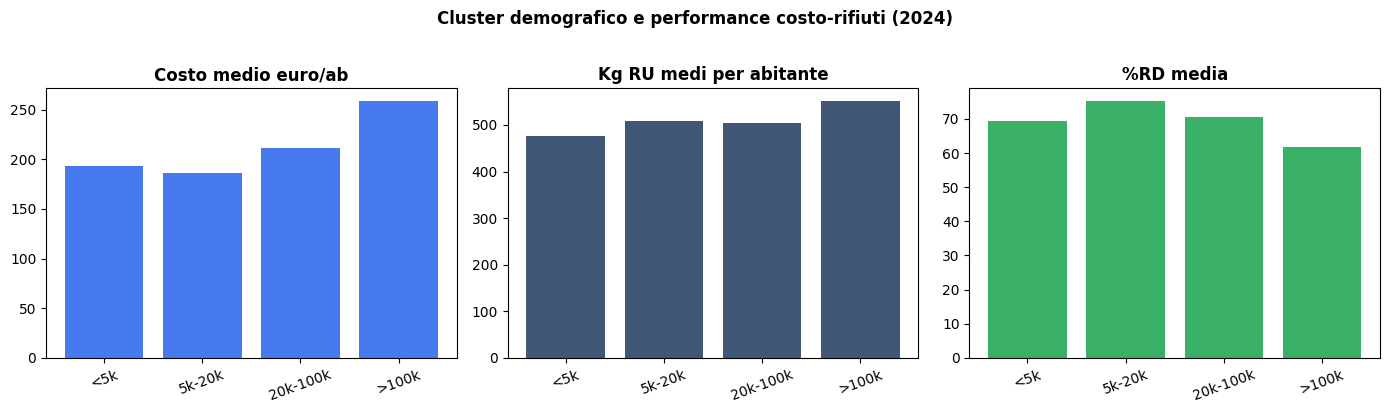

In [6]:
cluster_summary = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        cluster_demografico,
        COUNT(*) AS n_comuni,
        ROUND(AVG(costo_totale_euro_ab), 1) AS costo_ab,
        ROUND(AVG(kg_ru_per_abitante_calc), 1) AS kg_ab,
        ROUND(AVG(percentuale_rd), 1) AS pct_rd,
        ROUND(AVG(CASE WHEN quadrante_costo = 'Virtuoso costo-performance (RD alta, costo basso)' THEN 1 ELSE 0 END), 3) AS quota_virtuosi
    FROM t
    WHERE anno = 2024
      AND join_b_ok
      AND join_c_ok
    GROUP BY cluster_demografico
    ORDER BY CASE cluster_demografico WHEN '<5k' THEN 1 WHEN '5k-20k' THEN 2 WHEN '20k-100k' THEN 3 WHEN '>100k' THEN 4 ELSE 5 END
"""
).df()
cluster_summary

cluster_quadrants = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT cluster_demografico, quadrante_costo, COUNT(*) AS n_comuni
    FROM t
    WHERE anno = 2024
      AND join_b_ok
      AND join_c_ok
    GROUP BY cluster_demografico, quadrante_costo
    ORDER BY CASE cluster_demografico WHEN '<5k' THEN 1 WHEN '5k-20k' THEN 2 WHEN '20k-100k' THEN 3 WHEN '>100k' THEN 4 ELSE 5 END, quadrante_costo
"""
).df()
cluster_matrix = cluster_quadrants.pivot(index='cluster_demografico', columns='quadrante_costo', values='n_comuni').fillna(0).astype(int)
cluster_matrix

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cluster_order = cluster_summary['cluster_demografico']
axes[0].bar(cluster_order, cluster_summary['costo_ab'], color='#2563EB', alpha=0.85)
axes[0].set_title('Costo medio euro/ab', fontweight='bold')
axes[1].bar(cluster_order, cluster_summary['kg_ab'], color='#1E3A5F', alpha=0.85)
axes[1].set_title('Kg RU medi per abitante', fontweight='bold')
axes[2].bar(cluster_order, cluster_summary['pct_rd'], color='#16A34A', alpha=0.85)
axes[2].set_title('%RD media', fontweight='bold')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Cluster demografico e performance costo-rifiuti (2024)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Lettura interpretativa da aggiungere solo dopo il run finale del notebook.


## 6. Comuni turistici e casi anomali

Questa parte serve a non sovrainterpretare il costo per abitante dove il denominatore anagrafico e debole.
Esempi gia emersi pubblicamente: Foppolo, Monterosso, Portofino.


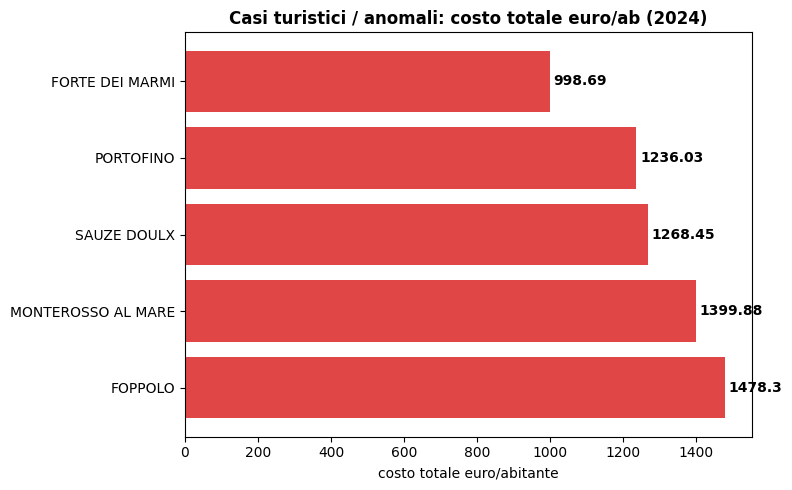

Nota metodologica: qui il denominatore anagrafico puo distorcere il costo per abitante. Il join ISTAT popolazione resta un approfondimento successivo, non un prerequisito del v2.


In [7]:
tourism_cases = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT
        comune,
        regione,
        regione_macro,
        cluster_demografico,
        ROUND(kg_ru_per_abitante_calc, 1) AS kg_ab,
        ROUND(costo_totale_euro_ab, 2) AS costo_ab,
        ROUND(percentuale_rd, 2) AS pct_rd,
        quadrante_costo
    FROM t
    WHERE anno = 2024
      AND join_b_ok
      AND join_c_ok
      AND UPPER(comune) IN ('FOPPOLO', 'MONTEROSSO AL MARE', 'PORTOFINO', 'FORTE DEI MARMI', 'SAUZE DOULX')
    ORDER BY costo_totale_euro_ab DESC
"""
).df()
tourism_cases

top_cost = con.execute(
    f"""WITH t AS ({union_sql})
    SELECT comune, regione, ROUND(costo_totale_euro_ab, 2) AS costo_ab, ROUND(percentuale_rd, 2) AS pct_rd, ROUND(kg_ru_per_abitante_calc, 1) AS kg_ab
    FROM t
    WHERE anno = 2024
      AND join_b_ok
      AND join_c_ok
    ORDER BY costo_totale_euro_ab DESC
    LIMIT 10
"""
).df()
top_cost

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tourism_cases['comune'], tourism_cases['costo_ab'], color='#DC2626', alpha=0.85)
for i, v in enumerate(tourism_cases['costo_ab']):
    ax.text(float(v) + 10, i, str(v), va='center', fontsize=10, fontweight='bold')
ax.set_title('Casi turistici / anomali: costo totale euro/ab (2024)', fontweight='bold')
ax.set_xlabel('costo totale euro/abitante')
plt.tight_layout()
plt.show()

print('Nota metodologica: qui il denominatore anagrafico puo distorcere il costo per abitante. Il join ISTAT popolazione resta un approfondimento successivo, non un prerequisito del v2.')


## 7. Nota metodologica finale

Da chiudere in modo esplicito:
- perimetro reale del campione;
- anni mancanti nel clone corrente;
- natura descrittiva del `quadrante_costo`;
- limite del denominatore anagrafico per i comuni turistici.


In [8]:
coverage_2024 = coverage.loc[coverage['anno'] == 2024].iloc[0]
missing_text = ', '.join(map(str, missing_years)) if missing_years else 'nessuno'
quad_lookup = dict(zip(quad_summary['quadrante_costo'], quad_summary['n_comuni']))
best_macro_rd = macro_summary.sort_values('pct_rd', ascending=False).iloc[0]
highest_macro_cost = macro_summary.sort_values('costo_ab', ascending=False).iloc[0]
best_cluster = cluster_summary.sort_values('quota_virtuosi', ascending=False).iloc[0]
top_tourism = top_cost.iloc[0]

summary_lines = [
    '## Sintesi finale v2',
    f"- Perimetro reale del clone: anni disponibili {', '.join(map(str, available_years))}; anni mancanti nel cross mart {missing_text}.",
    f"- Nel 2024 il join completo A + B + C copre {int(coverage_2024['comuni_join'])} comuni su {int(coverage_2024['comuni_ru'])} ({coverage_2024['copertura_pct']:.1f}%).",
    f"- Il quadrante_costo e' una classificazione descrittiva calcolata solo sul 2024: virtuosi {int(quad_lookup.get('Virtuoso costo-performance (RD alta, costo basso)', 0))}, criticita' su entrambi gli assi {int(quad_lookup.get('Criticità su entrambi gli assi (RD bassa, costo alto)', 0))}.",
    f"- Nel ponte 2020 -> 2023 la logica del pilota resta leggibile anche senza artifact locali: comuni virtuosi {int(bridge_summary.loc[0, 'comuni_virtuosi'])}, casi RD su / RU su {int(bridge_summary.loc[0, 'rd_su_ru_su'])}.",
    f"- Nel campione joinato 2024 la macro-area con %RD media piu' alta e' {best_macro_rd['regione_macro']} ({best_macro_rd['pct_rd']:.1f}), mentre il costo medio piu' alto e' in {highest_macro_cost['regione_macro']} ({highest_macro_cost['costo_ab']:.1f} euro/ab).",
    f"- Il cluster con quota piu' alta di comuni virtuosi e' {best_cluster['cluster_demografico']} ({best_cluster['quota_virtuosi']:.3f}), ma la lettura per cluster resta descrittiva e dipende dal campione joinato 2024.",
    f"- I casi turistici estremi restano utili come stress test, non come benchmark: nel 2024 il costo piu' alto nel campione joinato e' {top_tourism['comune']} ({top_tourism['regione']}) con {top_tourism['costo_ab']:.2f} euro/ab.",
    '- Limiti da tenere espliciti nel write-up finale: anni mancanti 2021(C) e 2022(B), natura non causale del quadrante_costo, possibile distorsione del denominatore anagrafico nei comuni turistici.'
]

print('\n'.join(summary_lines))


## Sintesi finale v2
- Perimetro reale del clone: anni disponibili 2020, 2023, 2024; anni mancanti nel cross mart 2021, 2022.
- Nel 2024 il join completo A + B + C copre 6477 comuni su 7671 (84.4%).
- Il quadrante_costo e' una classificazione descrittiva calcolata solo sul 2024: virtuosi 2018, criticita' su entrambi gli assi 0.
- Nel ponte 2020 -> 2023 la logica del pilota resta leggibile anche senza artifact locali: comuni virtuosi 1014, casi RD su / RU su 1190.
- Nel campione joinato 2024 la macro-area con %RD media piu' alta e' Nord (73.2), mentre il costo medio piu' alto e' in Centro (232.8 euro/ab).
- Il cluster con quota piu' alta di comuni virtuosi e' 5k-20k (0.378), ma la lettura per cluster resta descrittiva e dipende dal campione joinato 2024.
- I casi turistici estremi restano utili come stress test, non come benchmark: nel 2024 il costo piu' alto nel campione joinato e' FOPPOLO (Lombardia) con 1478.30 euro/ab.
- Limiti da tenere espliciti nel write-up finale: anni mancanti 

## 8. Export grafici e output riusabili

Questa parte resta separata dalla nota metodologica finale.
Serve solo a preparare asset riusabili per issue, Discussion o post interni.


In [9]:
export_dir = ROOT / 'out' / 'notebooks' / 'ispra-ru-costi-kg' / 'v2'
export_dir.mkdir(parents=True, exist_ok=True)

summary_path = export_dir / 'summary_github.md'
summary_path.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')

# Grafico 1: copertura e perimetro reale.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(coverage['anno'].astype(str), coverage['copertura_pct'], color='#2563EB', alpha=0.85)
for i, v in enumerate(coverage['copertura_pct']):
    axes[0].text(i, float(v) + 1, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Copertura join A + B + C', fontweight='bold')
axes[0].set_ylabel('% comuni con join completo')
axes[1].bar(coverage['anno'].astype(str), coverage['comuni_quadrante'], color='#16A34A', alpha=0.85)
for i, v in enumerate(coverage['comuni_quadrante']):
    axes[1].text(i, float(v) + 60, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Comuni con quadrante_costo valorizzato', fontweight='bold')
axes[1].set_ylabel('numero comuni')
plt.suptitle('Perimetro reale del v2 ISPRA RU costi', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(export_dir / 'perimetro_reale_v2.png', dpi=160, bbox_inches='tight')
plt.close(fig)

# Grafico 2: quadrante costo 2024.
sample = joined_2024[(joined_2024['join_b_ok']) & (joined_2024['join_c_ok'])].sample(min(2500, len(joined_2024[(joined_2024['join_b_ok']) & (joined_2024['join_c_ok'])])), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(quad_summary['quadrante_costo'], quad_summary['n_comuni'], color='#2563EB', alpha=0.85)
axes[0].set_title('Distribuzione del quadrante_costo', fontweight='bold')
axes[1].scatter(sample['percentuale_rd'], sample['costo_totale_euro_ab'], alpha=0.18, s=10, color='#16A34A')
axes[1].axvline(rd_threshold, color='#111827', linestyle='--', linewidth=1.2)
axes[1].axhline(costo_threshold, color='#DC2626', linestyle='--', linewidth=1.2)
axes[1].set_ylim(0, joined_2024['costo_totale_euro_ab'].quantile(0.98) * 1.1)
axes[1].set_title('%RD vs costo totale euro/abitante (2024)', fontweight='bold')
axes[1].set_xlabel('% raccolta differenziata')
axes[1].set_ylabel('costo totale euro/abitante')
plt.suptitle('Quadrante costo-performance sul campione 2024', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(export_dir / 'quadrante_costo_2024.png', dpi=160, bbox_inches='tight')
plt.close(fig)

# Grafico 3: confronto macro-aree.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ('costo_ab', 'Costo totale euro/ab', '#2563EB'),
    ('kg_ab', 'Kg RU/abitante', '#1E3A5F'),
    ('pct_rd', '% raccolta differenziata', '#16A34A'),
]
for ax, (col, title, color) in zip(axes, metrics):
    ax.bar(macro_summary['regione_macro'], macro_summary[col], color=color, alpha=0.85)
    for i, v in enumerate(macro_summary[col]):
        ax.text(i, float(v) + (2 if col != 'pct_rd' else 0.8), str(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('macro-area')
plt.suptitle('Nord / Centro / Sud sul campione joinato 2024', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(export_dir / 'macroaree_2024.png', dpi=160, bbox_inches='tight')
plt.close(fig)

quad_examples.to_csv(export_dir / 'quadrante_costo_esempi_2024.csv', index=False)
top_cost.to_csv(export_dir / 'top_costi_2024.csv', index=False)

print('Export completato in:')
for path in sorted(export_dir.iterdir()):
    print('-', path.name)


Export completato in:
- macroaree_2024.png
- perimetro_reale_v2.png
- quadrante_costo_2024.png
- quadrante_costo_esempi_2024.csv
- summary_github.md
- top_costi_2024.csv
